In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\functions\query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: kaggle


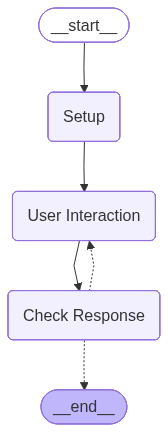

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
    
        if exp_id in processed_ids:
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Who were inducted into the Hall of Fame and what are their full names?


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Retrieve the full names (first, last, and given names) of players who were inducted into the Hall of Fame.",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_PLAYER", "KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "There are 312 players inducted into the Hall of Fame. Some examples include Hank Aaron (Henry Louis), Roberto Alomar (Roberto), Walter Alston (Walter Emmons), Sparky Anderson (George Lee), and Pete Alexander (Grover Cleveland).",
    "sql": "SELECT p.NAME_FIRST, p.NAME_LAST, p.NAME_GIVEN \nFROM KAGGLE.THEHISTORYOFBASEBALL_PLAYER p \nJOIN KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME h \nON p.PLAYER_ID = h.PLAYER_ID \nWHERE LOWER(h.INDUCTED) = LOWER('Y')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Retrieve the full names (first, last, and given names) of players who were inducted into the Hall of Fame.",
    "schema_linking": 

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME_FIRST', 'NAME_LAST'], dtype='object')
Adj. True cols: Index(['NAME_FIRST', 'NAME_LAST'], dtype='object')
Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'NAME_GIVEN'], dtype='object')
Adj. Predicted cols: Index(['NAME_FIRST', 'NAME_LAST'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Get the names of players inducted into the Hall of Fame.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Who were inducted into the Hall of Fame and what are their full names?', 'agent_reply': 'There are 312 players inducted into the Hall of Fame. Some examples include Hank Aaron (Henry Louis), Roberto Alomar (Roberto), Walter Alston (Walter Emmons), Sparky Anderson (George Lee), and Pete Alexander (Grover Cleveland).', 'evaluation': {'text_to_sql_input': 'Retrieve the full names (first, last, and given names) of players who were inducted into the Hall of Fame.', 'user_intention': 'Get the 

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "feedback",
    "schema_linking": "",
    "answer": "Could you clarify which players' salaries and voting year you are referring to? Are you asking about a specific Hall of Fame voting year or a group of players previously mentioned?",
    "sql": ""
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "feedback",
    "schema_linking": "",
    "answer": "Could you clarify which players' salaries and voting year you are referring to? Are you asking about a specific Hall of Fame voting year or a group of players previously mentioned?",
    "sql": ""
}.

[INFO] Avaliando o resultado: {'input': 'feedback', 'schema_linking': '', 'answer': "Could you clarify which players' salaries and voting year you are referring to? Are you asking about a specific Hall of Fame voting year or a group of players previously mentioned?", 'sql': ''}.

[AI as JUDGE] Judging if a feedb

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Retrieve the salaries of players in the same year they participated in the Hall of Fame voting.",
    "schema_linking": ["THEHISTORYOFBASEBALL_SALARY", "THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "One example is player 'francju02', who earned a salary of $496,250 in 2013, the same year they participated in Hall of Fame voting.",
    "sql": "SELECT s.PLAYER_ID, s.YEAR, s.SALARY FROM KAGGLE.THEHISTORYOFBASEBALL_SALARY s JOIN KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME h ON s.PLAYER_ID = h.PLAYER_ID WHERE s.YEAR = h.YEARID"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Retrieve the salaries of players in the same year they participated in the Hall of Fame voting.",
    "schema_linking": ["THEHISTORYOFBASEBALL_SALARY", "THEHISTORYOFBASEBALL_HALL_OF_FAME"],
    "answer": "One example is player 'francju02', who earned a salary of $496,250 in 2013, th

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
